[INFO] Using connectivity metric: wpli2_debiased
[INFO] Epoch length (s): 5.0


/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_48764/661300221.py:55: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_48764/661300221.py:55: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_48764/661300221.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_48764/661300221.py:55: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be

[INFO] Phase 1 collected 88 subjects.
[INFO] Phase 2 built CN-anchored composite for all subjects.
[INFO] Saved per-subject broadband summary → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_broadband_summary.csv
               mean       std  count
group                               
AD     1.794076e-01  0.265770     36
CN    -5.742533e-18  0.201711     29
FTD    1.101774e-01  0.339125     23


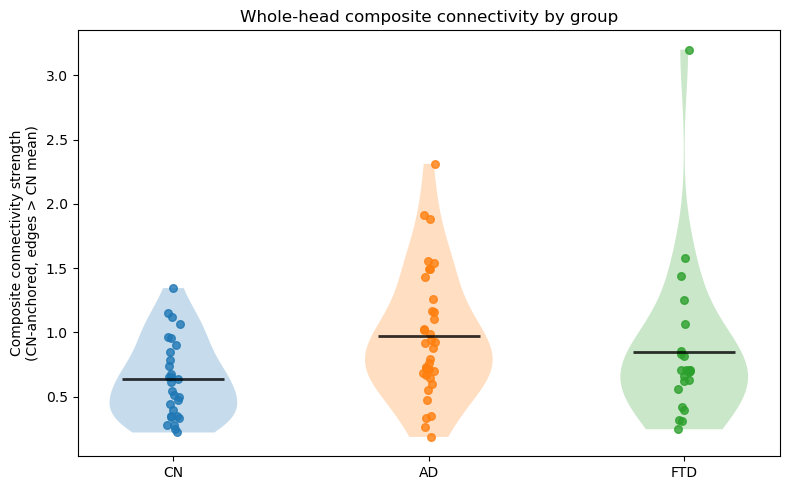

[INFO] Saved strength violin → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_broadband_strength_violin.png


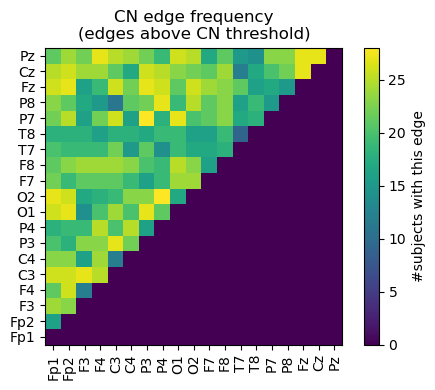

[INFO] Saved edge-frequency heatmap → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_edgefreq_CN.png


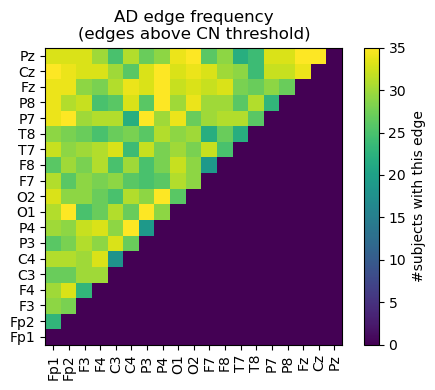

[INFO] Saved edge-frequency heatmap → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_edgefreq_AD.png


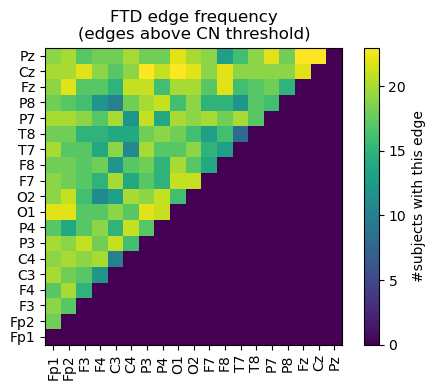

[INFO] Saved edge-frequency heatmap → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_edgefreq_FTD.png


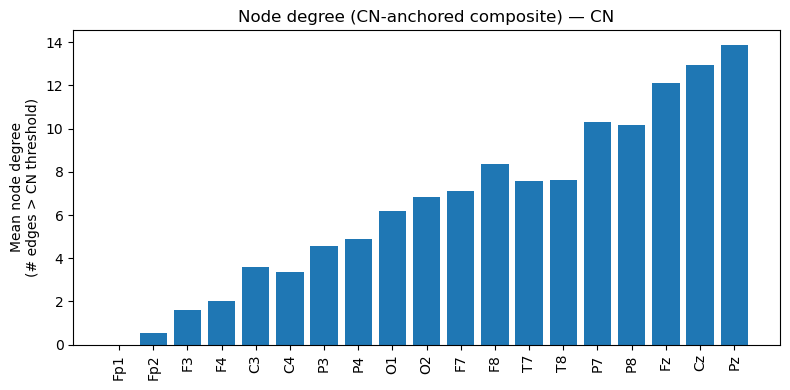

[INFO] Saved node-degree plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_nodeDegree_CN.png


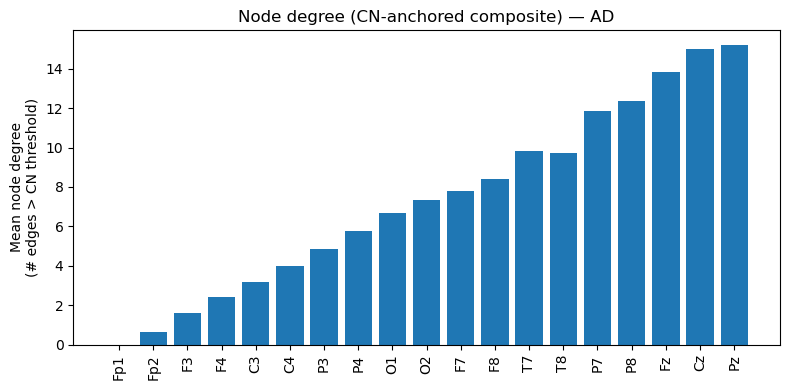

[INFO] Saved node-degree plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_nodeDegree_AD.png


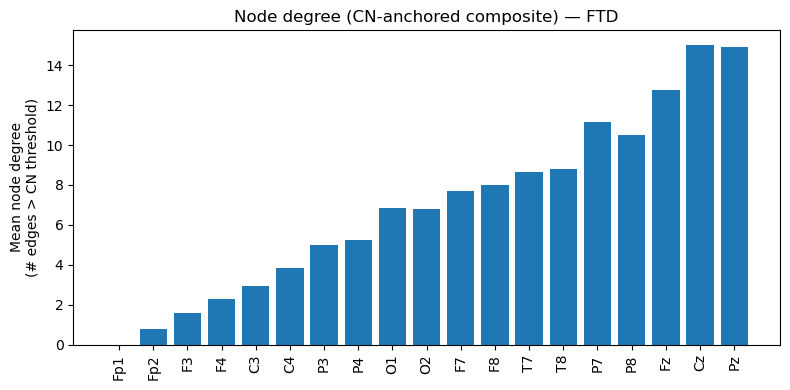

[INFO] Saved node-degree plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/blockX_normalized/blockX_nodeDegree_FTD.png
[INFO] Saved blockX_strength_ANOVA.csv and blockX_strength_pairwise.csv
[INFO] Block X complete.


In [18]:
# ===========================
# Block X — Broadband Whole-Head Connectivity
# CN-anchored composite connectivity (delta/theta/alpha/beta)
# ===========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne_connectivity import spectral_connectivity_epochs

# -----------------
# Config
# -----------------

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
DATA_ROOT = ROOT / "outputs"

OUTDIR = ROOT / "outputs" / "connectivity" / "blockX_normalized"
OUTDIR.mkdir(parents=True, exist_ok=True)

PARTIC = ROOT / "participants.tsv"  # has participant_id, Group (C/A/F), etc.

EPOCH_LEN = 5.0  # seconds, updated
GROUP_MAP = {
    "C": "CN",   # cognitively normal
    "A": "AD",   # Alzheimer's
    "F": "FTD",  # frontotemporal dementia
}
GROUP_ORDER = ["CN", "AD", "FTD"]

PREFERRED_METHODS = ["wpli2_debiased", "wpli"]  # we'll prefer debiased wPLI


# -----------------
# Helper functions
# -----------------

def load_group_table(participants_path: Path) -> dict:
    dfp = pd.read_csv(participants_path, sep="\t")
    dfp["sub_id_core"] = dfp["participant_id"].str.replace("^sub-", "", regex=True)
    dfp["group_pretty"] = dfp["Group"].map(GROUP_MAP)
    return dict(zip(dfp["sub_id_core"], dfp["group_pretty"]))

def choose_wpli_method():
    return PREFERRED_METHODS[0]

def epochs_for_subject_fullhead(set_path: Path, epoch_len_s: float):
    """
    Load one subject's cleaned EEGLAB .set,
    keep EEG only,
    cut into non-overlapping epochs of length epoch_len_s.
    """
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # rename legacy labels T3->T7 etc so montage works
    rename_map = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
    present = {old: new for old, new in rename_map.items() if old in raw.ch_names}
    if len(present) > 0:
        raw.rename_channels(present)

    # add 10-20 montage for positions
    try:
        raw.set_montage("standard_1020", match_case=False)
    except Exception as e:
        print(f"[WARN] montage set failed for {set_path.name}: {e}")

    # EEG only
    picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, misc=False)
    if len(picks) < 2:
        return None, []

    raw_eeg = raw.copy().pick(picks)
    ch_names_kept = raw_eeg.ch_names
    sfreq = raw_eeg.info["sfreq"]

    # assume already ~1-45 Hz filtered upstream

    # build fixed events for epoch_len_s
    n_samples = raw_eeg.n_times
    seglen = int(round(epoch_len_s * sfreq))
    onsets = np.arange(0, n_samples - seglen + 1, seglen, dtype=int)
    n_epochs = len(onsets)
    if n_epochs < 2:
        return None, ch_names_kept

    events = np.c_[onsets,
                   np.zeros(n_epochs, dtype=int),
                   np.ones(n_epochs, dtype=int)]

    epochs_full = mne.Epochs(
        raw_eeg,
        events=events.astype(int),
        event_id={"dummy": 1},
        tmin=0.0,
        tmax=epoch_len_s - 1.0 / sfreq,
        baseline=None,
        preload=True,
        reject=None,
        verbose=False,
    )

    return epochs_full, ch_names_kept

def compute_connectivity_matrix(epochs_obj, fmin, fmax, method_name="wpli2_debiased"):
    """
    Connectivity matrix for [fmin,fmax].
    Returns (n_ch, n_ch) dense.
    """
    data = epochs_obj.get_data()  # (n_epochs, n_ch, n_times)

    conn = spectral_connectivity_epochs(
        data,
        method=method_name,
        sfreq=epochs_obj.info["sfreq"],
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        verbose=False,
    )

    mat = conn.get_data(output="dense")
    mat = np.squeeze(mat)
    return mat  # shape (n_ch,n_ch)

BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 7.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 40.0)
}

def offdiag_values(mat2d: np.ndarray):
    """Return 1D array of off-diagonal entries."""
    n = mat2d.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return mat2d[mask]

def apply_control_z(mat_band: np.ndarray, mu_ctrl: float, sd_ctrl: float):
    """
    Z using CONTROL (CN) baseline:
    z = (edge - mu_ctrl) / sd_ctrl
    diagonal forced 0.
    """
    z_mat = np.zeros_like(mat_band)
    mask_off = ~np.eye(mat_band.shape[0], dtype=bool)
    if sd_ctrl == 0:
        sd_ctrl = 1.0
    z_mat[mask_off] = (mat_band[mask_off] - mu_ctrl) / sd_ctrl
    return z_mat

def node_degree_from_masked(masked_mat: np.ndarray):
    """
    Node degree = count of non-zero off-diagonal edges per node.
    """
    n = masked_mat.shape[0]
    deg = np.zeros(n, dtype=float)
    for i in range(n):
        row = masked_mat[i, :].copy()
        row[i] = 0.0
        deg[i] = np.count_nonzero(row)
    return deg


# -----------------
# PHASE 1: gather raw per-band matrices for every subject
# -----------------

METHOD_NAME = choose_wpli_method()
print(f"[INFO] Using connectivity metric: {METHOD_NAME}")
print(f"[INFO] Epoch length (s): {EPOCH_LEN}")

group_lookup = load_group_table(PARTIC)

# we'll hold everything here first
subjects_info = []  # list of dicts (one per subject) holding raw band mats etc.
group_ch_names = None

for sub_dir in sorted(DATA_ROOT.glob("sub-*")):
    sub_id_core = sub_dir.name.replace("sub-", "")  # e.g. "001"

    if sub_id_core not in group_lookup:
        print(f"[WARN] cannot determine group for {sub_dir.name}, skip.")
        continue
    group_code = group_lookup[sub_id_core]  # "CN","AD","FTD"

    # find cleaned_final.set
    set_files = sorted(sub_dir.glob("*cleaned_final.set"))
    if len(set_files) == 0:
        print(f"[WARN] {sub_dir.name}: no *_cleaned_final.set, skip.")
        continue
    set_path = set_files[0]

    # epochs
    epochs_full, ch_names = epochs_for_subject_fullhead(set_path, EPOCH_LEN)
    if epochs_full is None or len(epochs_full) < 2:
        print(f"[WARN] {sub_dir.name}: not enough usable data for epochs, skip.")
        continue

    # lock channel order (must match across subjects)
    if group_ch_names is None:
        group_ch_names = ch_names
    else:
        if ch_names != group_ch_names:
            print(f"[WARN] {sub_dir.name}: channel mismatch vs first subject, skip.")
            continue

    # get raw connectivity matrices for each band (no normalization yet)
    band_raw = {}
    for band_name, (lo, hi) in BANDS.items():
        mat_band = compute_connectivity_matrix(
            epochs_full,
            fmin=lo,
            fmax=hi,
            method_name=METHOD_NAME
        )
        band_raw[band_name] = mat_band

        # save raw for record/debug
        np.save(
            OUTDIR / f"{sub_dir.name}_{band_name}_rawConn.npy",
            mat_band
        )

    subjects_info.append({
        "subj_core": sub_id_core,
        "group": group_code,
        "n_epochs": len(epochs_full),
        "n_ch": len(ch_names),
        "band_raw": band_raw,
    })

print(f"[INFO] Phase 1 collected {len(subjects_info)} subjects.")


# -----------------
# PHASE 2: build CONTROL (CN) baseline stats per band
# -----------------

control_band_stats = {}  # band -> dict(mu, sd)

for band_name in BANDS.keys():
    all_cn_edges = []
    for s in subjects_info:
        if s["group"] != "CN":
            continue
        mat_band = s["band_raw"][band_name]
        all_cn_edges.append(offdiag_values(mat_band))

    if len(all_cn_edges) == 0:
        # no CN in dataset for this band? fallback avoid crash
        mu_ctrl = 0.0
        sd_ctrl = 1.0
    else:
        all_cn_edges_concat = np.concatenate(all_cn_edges)
        mu_ctrl = float(all_cn_edges_concat.mean())
        sd_ctrl = float(all_cn_edges_concat.std(ddof=1))
        if sd_ctrl == 0:
            sd_ctrl = 1.0

    control_band_stats[band_name] = {
        "mu": mu_ctrl,
        "sd": sd_ctrl,
    }

# Now we can create CN-anchored z-maps per band and composite per subject
for s in subjects_info:
    z_mats_per_band = []
    for band_name, (lo, hi) in BANDS.items():
        mat_band = s["band_raw"][band_name]
        mu_ctrl = control_band_stats[band_name]["mu"]
        sd_ctrl = control_band_stats[band_name]["sd"]
        z_mat = apply_control_z(mat_band, mu_ctrl, sd_ctrl)
        z_mats_per_band.append(z_mat)
    # equal-weight mean across bands
    comp_mat = np.mean(np.stack(z_mats_per_band, axis=0), axis=0)
    s["comp_mat_CNanchored"] = comp_mat

    # save this composite CN-anchored matrix
    np.save(
        OUTDIR / f"sub-{s['subj_core']}_compositeConn_CNanchor.npy",
        comp_mat
    )

print("[INFO] Phase 2 built CN-anchored composite for all subjects.")

# =====================================================
# Phase 2.5 — Save per-subject CN-anchored broadband strength summary
# =====================================================

import pandas as pd
from pathlib import Path
import numpy as np

OUTDIR_SUMMARY = OUTDIR  # same folder as existing outputs

summary_rows = []
for s in subjects_info:
    subj_id = s["subj_core"]
    group = s["group"]
    comp_mat = s.get("comp_mat_CNanchored", None)
    if comp_mat is None:
        continue

    # --- compute global broadband connectivity strength ---
    vals = offdiag_values(comp_mat)
    strength_mean = float(np.mean(vals))
    strength_std = float(np.std(vals, ddof=1))

    summary_rows.append({
        "subj": subj_id,
        "group": group,
        "Strength_broadband": strength_mean,
        "Strength_broadband_std": strength_std,
        "n_ch": comp_mat.shape[0],
        "n_edges": len(vals)
    })

# Convert to DataFrame and save
df_summary = pd.DataFrame(summary_rows)
save_path = OUTDIR_SUMMARY / "blockX_broadband_summary.csv"
df_summary.to_csv(save_path, index=False)
print(f"[INFO] Saved per-subject broadband summary → {save_path}")
print(df_summary.groupby('group')["Strength_broadband"].agg(['mean','std','count']))


# -----------------
# GROUP-LEVEL VISUALS
# -----------------

# 1. Edge-frequency heatmap per group
group_edgefreq = {}
group_nodedegree = {}

for grp_code in GROUP_ORDER:
    mats_list = group_all_masked.get(grp_code, [])
    deg_list = group_all_degrees.get(grp_code, [])

    if len(mats_list) == 0:
        continue

    n_ch = mats_list[0].shape[0]

    # edge frequency: how many subjects have this edge above CN threshold
    freq_mat = np.zeros((n_ch, n_ch), dtype=float)
    for mm in mats_list:
        freq_mat += (mm > 0).astype(float)

    group_edgefreq[grp_code] = freq_mat

    # node degree across subjects: average degree per node
    deg_arr = np.stack(deg_list, axis=0)  # (n_subj_grp, n_ch)
    mean_deg = deg_arr.mean(axis=0)
    group_nodedegree[grp_code] = mean_deg

    # save CSVs
    pd.DataFrame(freq_mat, index=group_ch_names, columns=group_ch_names).to_csv(
        OUTDIR / f"group_{grp_code}_edgeFrequency.csv"
    )
    pd.DataFrame(mean_deg, index=group_ch_names,
                 columns=["mean_node_degree"]).to_csv(
        OUTDIR / f"group_{grp_code}_nodeDegree.csv"
    )

# 2. Violin / scatter of Strength_broadband
vals_by_group = []
colors = []
palette = {
    "CN": "#1f77b4",
    "AD": "#ff7f0e",
    "FTD": "#2ca02c",
}

for g in GROUP_ORDER:
    arr = df_blockX.loc[df_blockX["group"] == g, "Strength_broadband"].dropna().values
    vals_by_group.append(arr)
    colors.append(palette.get(g, "gray"))

fig, ax = plt.subplots(figsize=(8,5))
parts = ax.violinplot(
    vals_by_group,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c)
    pc.set_alpha(0.25)
    pc.set_edgecolor('none')

for i, (grp, arr) in enumerate(zip(GROUP_ORDER, vals_by_group), start=1):
    if len(arr) == 0:
        continue
    ax.scatter(
        np.full_like(arr, i, dtype=float) + (np.random.rand(len(arr))-0.5)*0.05,
        arr,
        color=palette.get(grp, "gray"),
        s=30,
        alpha=0.8,
        zorder=3
    )
    ax.hlines(
        y=np.mean(arr),
        xmin=i-0.2,
        xmax=i+0.2,
        color="black",
        linewidth=2,
        alpha=0.8,
        zorder=4
    )

ax.set_xticks([1,2,3])
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel("Composite connectivity strength\n(CN-anchored, edges > CN mean)")
ax.set_title("Whole-head composite connectivity by group")
fig.tight_layout()

violin_path = OUTDIR / "blockX_broadband_strength_violin.png"
fig.savefig(violin_path, dpi=300)
plt.show()
print(f"[INFO] Saved strength violin → {violin_path}")

# 3. Edge-frequency heatmap figure per group
for grp_code in GROUP_ORDER:
    if grp_code not in group_edgefreq:
        continue

    freq_mat = group_edgefreq[grp_code]

    fig2, ax2 = plt.subplots(figsize=(5,4))
    im = ax2.imshow(freq_mat, origin="lower")
    ax2.set_title(f"{grp_code} edge frequency\n(edges above CN threshold)")
    ax2.set_xticks(range(len(group_ch_names)))
    ax2.set_yticks(range(len(group_ch_names)))
    ax2.set_xticklabels(group_ch_names, rotation=90)
    ax2.set_yticklabels(group_ch_names)
    fig2.colorbar(im, ax=ax2, label="#subjects with this edge")
    fig2.tight_layout()

    heatmap_path = OUTDIR / f"blockX_edgefreq_{grp_code}.png"
    fig2.savefig(heatmap_path, dpi=300)
    plt.show()
    print(f"[INFO] Saved edge-frequency heatmap → {heatmap_path}")

# 4. Node-degree barplot per group
for grp_code in GROUP_ORDER:
    if grp_code not in group_nodedegree:
        continue
    mean_deg = group_nodedegree[grp_code]

    fig3, ax3 = plt.subplots(figsize=(8,4))
    ax3.bar(range(len(group_ch_names)), mean_deg)
    ax3.set_xticks(range(len(group_ch_names)))
    ax3.set_xticklabels(group_ch_names, rotation=90)
    ax3.set_ylabel("Mean node degree\n(# edges > CN threshold)")
    ax3.set_title(f"Node degree (CN-anchored composite) — {grp_code}")
    fig3.tight_layout()

    degplot_path = OUTDIR / f"blockX_nodeDegree_{grp_code}.png"
    fig3.savefig(degplot_path, dpi=300)
    plt.show()
    print(f"[INFO] Saved node-degree plot → {degplot_path}")


# -----------------
# BASIC STATS (ANOVA on Strength_broadband)
# -----------------
try:
    from scipy import stats
    import itertools

    data_groups = []
    labels_groups = []
    for g in GROUP_ORDER:
        vals = df_blockX.loc[df_blockX["group"] == g, "Strength_broadband"].dropna().values
        if len(vals) > 0:
            data_groups.append(vals)
            labels_groups.append(g)

    if len(data_groups) >= 2:
        F, p_anova = stats.f_oneway(*data_groups)
    else:
        F, p_anova = np.nan, np.nan

    pair_rows = []
    for g1, g2 in itertools.combinations(GROUP_ORDER, 2):
        vals1 = df_blockX.loc[df_blockX["group"] == g1, "Strength_broadband"].dropna().values
        vals2 = df_blockX.loc[df_blockX["group"] == g2, "Strength_broadband"].dropna().values
        if len(vals1) > 1 and len(vals2) > 1:
            tval, pval = stats.ttest_ind(vals1, vals2, equal_var=False)
        else:
            tval, pval = np.nan, np.nan
        pair_rows.append({
            "Group1": g1,
            "Group2": g2,
            "tval": tval,
            "pval_raw": pval,
        })

    # Bonferroni correction
    for r in pair_rows:
        r["pval_bonf"] = min(r["pval_raw"] * len(pair_rows), 1.0)

    pd.DataFrame([{
        "anova_F": F,
        "anova_p": p_anova,
    }]).to_csv(OUTDIR / "blockX_strength_ANOVA.csv", index=False)

    pd.DataFrame(pair_rows).to_csv(OUTDIR / "blockX_strength_pairwise.csv", index=False)

    print("[INFO] Saved blockX_strength_ANOVA.csv and blockX_strength_pairwise.csv")

except Exception as e:
    print(f"[WARN] Stats section failed (scipy maybe missing): {e}")

print("[INFO] Block X complete.")

In [19]:
from pathlib import Path
import pandas as pd

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
csv_path = ROOT / "outputs" / "connectivity" / "blockX_normalized" / "blockX_broadband_summary.csv"

df = pd.read_csv(csv_path)
display(df.groupby("group")["Strength_broadband"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False))


,mean,std,count
group,,,
AD,0.179408,0.265770,36
FTD,0.110177,0.339125,23
CN,0.000000,0.201711,29



===== Broadband Strength (CN-anchored) =====

[Classical ANOVA]
    Source        SS  DF        MS         F     p-unc       np2
0   group  0.518961   2  0.259480  3.591251  0.031823  0.077916
1  Within  6.141545  85  0.072253       NaN       NaN       NaN

[Pairwise comparisons]
   Contrast   A    B  Paired  Parametric         T        dof alternative  \
0    group  AD   CN   False        True  3.092750  62.807501   two-sided   
1    group  AD  FTD   False        True  0.829697  38.888798   two-sided   
2    group  CN  FTD   False        True -1.376868  33.976199   two-sided   

      p-unc    p-corr p-adjust    BF10     cohen  
0  0.002958  0.008873     bonf  12.497  0.749328  
1  0.411774  1.000000     bonf   0.359  0.233694  
2  0.177558  0.532675     bonf   0.607 -0.406707  

Descriptive stats:
            mean       std  count
group                           
AD     0.179408  0.265770     36
CN     0.000000  0.201711     29
FTD    0.110177  0.339125     23


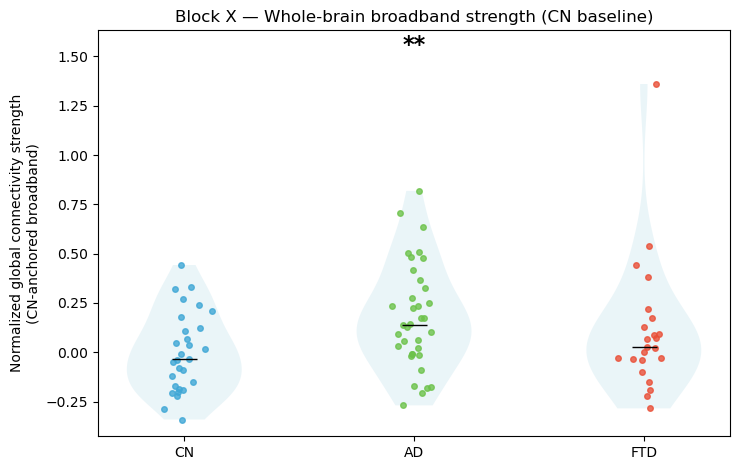

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_broadband_strength_violin.png
[i] ANOVA: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_Broadband_Strength_(CN-anchored)_ANOVA.csv
[i] Pairwise: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_Broadband_Strength_(CN-anchored)_pairwise.csv


In [20]:
# =====================================================
# Block X: Group Statistics — CN-Anchored Broadband Strength
# =====================================================
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "blockX_normalized" / "blockX_broadband_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "blockX"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
merged = pd.read_csv(IN_CSV)

# =====================================================
# Helper function for the broadband (CN-normalized) strength
# =====================================================
def run_stats_blockX(value_col: str = "Strength_broadband", label: str = "Broadband Strength (CN-anchored)"):
    print(f"\n===== {label} =====")

    # Prepare working copy
    df = merged[["group", value_col]].copy()
    df.rename(columns={value_col: "strength"}, inplace=True)

    # ---------- ANOVA ----------
    anova_res = pg.anova(data=df, dv="strength", between="group", detailed=True)
    anova_path = SAVE_DIR / f"blockX_{label.replace(' ', '_')}_ANOVA.csv"
    anova_res.to_csv(anova_path, index=False)
    print("\n[Classical ANOVA]\n", anova_res)

    # ---------- Pairwise ----------
    pairwise = pg.pairwise_tests(
        data=df, dv="strength", between="group",
        padjust="bonf", effsize="cohen"
    )
    pairwise_path = SAVE_DIR / f"blockX_{label.replace(' ', '_')}_pairwise.csv"
    pairwise.to_csv(pairwise_path, index=False)
    print("\n[Pairwise comparisons]\n", pairwise)

    # ---------- Summary ----------
    summary = df.groupby("group")["strength"].agg(["mean", "std", "count"])
    print("\nDescriptive stats:\n", summary)

    # ---------- Significance vs CN ----------
    sig_results = []
    for _, row in pairwise.iterrows():
        if "CN" in (row["A"], row["B"]) and row["p-corr"] < 0.05:
            g1, g2 = row["A"], row["B"]
            if g1 != "CN":
                g1, g2 = g2, g1
            sig_results.append((g2, row["p-corr"]))

    def p_to_star(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    # ---------- Visualization ----------
    order = ["CN", "AD", "FTD"]
    df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)
    df = df.sort_values("group")

    plt.figure(figsize=(7.5, 4.8))
    groups = [g for g in order if g in set(df["group"])]
    data = [df.loc[df["group"] == g, "strength"].values for g in groups]

    # Violin (light blue)
    parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor("lightblue")
        pc.set_alpha(0.25)

    # Scatter dots per group
    dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN blue, AD green, FTD red
    for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
        if len(vals) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

    # Group medians
    medians = [np.median(v) if len(v) else np.nan for v in data]
    plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
             color="black", markersize=18)

    plt.xticks(range(1, len(groups) + 1), groups)
    plt.ylabel("Normalized global connectivity strength\n(CN-anchored broadband)")
    plt.title("Block X — Whole-brain broadband strength (CN baseline)")

    # ---------- Significance stars ----------
    ymax = max([np.max(v) for v in data if len(v) > 0])
    offset = ymax * 0.1
    for group, p in sig_results:
        star = p_to_star(p)
        if star:
            idx = order.index(group) + 1
            plt.text(idx, ymax + offset, star,
                     ha="center", va="bottom", fontsize=16,
                     color="black", fontweight="bold")

    plt.ylim(None, ymax + offset * 2)
    plt.tight_layout()

    # ---------- Save ----------
    fig_path = SAVE_DIR / "blockX_broadband_strength_violin.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()

    print(f"[i] Figure saved: {fig_path}")
    print(f"[i] ANOVA: {anova_path}")
    print(f"[i] Pairwise: {pairwise_path}")


# =====================================================
# Run Block X stats
# =====================================================
run_stats_blockX()


[i] Loaded 88 entries from blockX_broadband_summary.csv
   subj group  Strength_broadband  Strength_broadband_std  n_ch  n_edges
0     1    AD            0.708438                1.552416    19      342
1     2    AD            0.032697                0.618223    19      342
2     3    AD            0.058883                0.677932    19      342
[Permutation ANOVA] Observed F = 3.591, p_perm = 0.0296


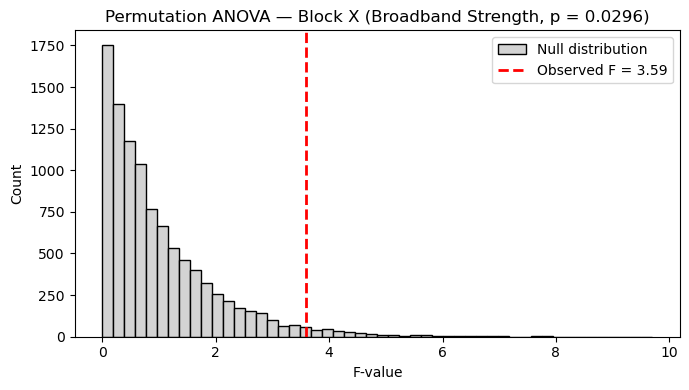

[i] Permutation histogram saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_permutation_ANOVA_hist.png
[i] Summary text → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_permutation_summary.txt


In [21]:
# =====================================================
# Block X (Normalized CN-Anchored) — Permutation ANOVA
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pingouin import anova
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "blockX_normalized" / "blockX_broadband_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "blockX"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(IN_CSV)
df.rename(columns={"group": "group", "Strength_broadband": "Strength_broadband"}, inplace=True)
print(f"[i] Loaded {len(df)} entries from {IN_CSV.name}")
print(df.head(3))

# ---------- Permutation ANOVA ----------
def perm_anova(df, n_perm=10000, seed=42):
    np.random.seed(seed)
    real_F = anova(data=df, dv="Strength_broadband", between="group", detailed=True)["F"].values[0]
    perm_F = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = df.copy()
        shuffled["group"] = np.random.permutation(shuffled["group"].values)
        perm_F[i] = anova(data=shuffled, dv="Strength_broadband", between="group", detailed=True)["F"].values[0]
    p_perm = np.mean(perm_F >= real_F)
    return real_F, p_perm, perm_F

# ---------- Run ----------
real_F, p_perm, perm_F = perm_anova(df, n_perm=10000)
print(f"[Permutation ANOVA] Observed F = {real_F:.3f}, p_perm = {p_perm:.4f}")

# ---------- Save ----------
np.save(SAVE_DIR / "blockX_permutation_Fdist.npy", perm_F)
with open(SAVE_DIR / "blockX_permutation_summary.txt", "w") as f:
    f.write(f"Observed F = {real_F:.3f}\n")
    f.write(f"Permutation p = {p_perm:.5f}\n")
    f.write(f"n_perm = {len(perm_F)}\n")

# ---------- Visualization ----------
plt.figure(figsize=(7, 4))
plt.hist(perm_F, bins=50, color="lightgray", edgecolor="black", label="Null distribution")
plt.axvline(real_F, color="red", linestyle="--", lw=2, label=f"Observed F = {real_F:.2f}")
plt.xlabel("F-value")
plt.ylabel("Count")
plt.title(f"Permutation ANOVA — Block X (Broadband Strength, p = {p_perm:.4f})")
plt.legend()
plt.tight_layout()

out_path = SAVE_DIR / "blockX_permutation_ANOVA_hist.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[i] Permutation histogram saved → {out_path}")
print(f"[i] Summary text → {SAVE_DIR / 'blockX_permutation_summary.txt'}")


In [22]:
# =====================================================
# Covariate Check — participants.tsv
# =====================================================

import pandas as pd
import numpy as np
import pingouin as pg
from scipy import stats
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
PARTIC_PATH = ROOT / "participants.tsv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(PARTIC_PATH, sep="\t")
print(f"[i] Loaded {len(df)} participants from {PARTIC_PATH.name}")
print(df.head())

# Rename columns if necessary (standardize names)
df.rename(columns={c: c.strip().capitalize() for c in df.columns}, inplace=True)

# Basic summary
print("\n[Group counts]")
print(df["Group"].value_counts())

# ---------- Continuous Covariates ----------
def run_continuous_covariate(df, var):
    print(f"\n===== {var.upper()} =====")
    # 1. Descriptive stats
    summary = df.groupby("Group")[var].describe()[["mean", "std", "count"]]
    print(summary)

    # 2. Normality check (Shapiro)
    for g in df["Group"].unique():
        w, p = stats.shapiro(df.loc[df["Group"] == g, var].dropna())
        print(f"  Shapiro–Wilk ({g}): W={w:.3f}, p={p:.3f}")

    # 3. Homogeneity of variance
    w, p = stats.levene(
        *[df.loc[df["Group"] == g, var].dropna() for g in df["Group"].unique()]
    )
    print(f"  Levene test: W={w:.3f}, p={p:.3f}")

    # 4. Parametric ANOVA or Kruskal based on normality
    if all(stats.shapiro(df.loc[df["Group"] == g, var].dropna())[1] > 0.05 for g in df["Group"].unique()):
        aov = pg.anova(data=df, dv=var, between="Group", detailed=True)
        print(aov)
    else:
        H, p_kw = stats.kruskal(
            *[df.loc[df["Group"] == g, var].dropna() for g in df["Group"].unique()]
        )
        print(f"  Kruskal–Wallis: H={H:.3f}, p={p_kw:.4f}")

# Run for key covariates
run_continuous_covariate(df, "Age")
run_continuous_covariate(df, "Mmse")

# ---------- Categorical Covariates ----------
print("\n===== GENDER =====")
tab = pd.crosstab(df["Group"], df["Gender"])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(tab)
print(f"Chi-square = {chi2:.3f}, df={dof}, p={p:.4f}")

# ---------- Optional ANCOVA Example ----------
# Adjust group effect in Block X broadband strength for Age

broadband_path = ROOT / "outputs" / "connectivity" / "blockX_normalized" / "blockX_broadband_summary.csv"

if broadband_path.exists():
    dfx = pd.read_csv(broadband_path)
    # make subj string and zero-padded (e.g., "001")
    dfx["subj"] = dfx["subj"].astype(str).str.zfill(3)

    # prepare participants table to match: strip "sub-" → "001"
    df["Participant_id_core"] = (
        df["Participant_id"]
        .astype(str)
        .str.replace("^sub-", "", regex=True)
        .str.zfill(3)
    )

    # merge using harmonized IDs
    df_merged = pd.merge(
        dfx,
        df,
        left_on="subj",
        right_on="Participant_id_core",
        how="left"
    )

    # run ANCOVA
    ancova = pg.ancova(data=df_merged, dv="Strength_broadband", covar="Age", between="Group")
    print("\n===== ANCOVA (Broadband Strength adjusted for Age) =====")
    print(ancova)

    ancova.to_csv(SAVE_DIR / "covariatecheck_ANCOVA.csv", index=False)
else:
    print("\n[WARN] Broadband summary not found — skipping ANCOVA section.")


# ---------- Save text summary ----------
out_txt = SAVE_DIR / "covariatecheck_summary.txt"
with open(out_txt, "w") as f:
    f.write("Covariate Check Summary\n=========================\n\n")
    f.write(f"N = {len(df)} participants\n\n")
    f.write(str(df["Group"].value_counts()) + "\n\n")
    f.write("See console output for detailed test results.\n")

print(f"\n[i] Summary saved → {out_txt}")


[i] Loaded 88 participants from participants.tsv
  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22

[Group counts]
Group
A    36
C    29
F    23
Name: count, dtype: int64

===== AGE =====
            mean       std  count
Group                            
A      66.388889  7.889515   36.0
C      67.896552  5.400693   29.0
F      63.652174  8.221970   23.0
  Shapiro–Wilk (A): W=0.968, p=0.374
  Shapiro–Wilk (C): W=0.969, p=0.531
  Shapiro–Wilk (F): W=0.968, p=0.637
  Levene test: W=2.133, p=0.125
   Source           SS  DF          MS         F     p-unc      np2
0   Group   233.980580   2  116.990290  2.218462  0.115037  0.04961
1  Within  4482.462602  85   52.734854       NaN       NaN      NaN

===== MMSE =====
            mean       std  count
Group                            
A      17.750

/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [27]:
# =====================================================
# Block X — Graph-Theoretic Metrics + 95 % CIs (add-on)
# =====================================================

import networkx as nx
import pingouin as pg
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
WPLI_DIR = ROOT / "outputs" / "connectivity" / "blockX_normalized"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "blockX"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load per-subject broadband summary ----------
df = pd.read_csv(WPLI_DIR / "blockX_broadband_summary.csv")
print(f"[i] Loaded {len(df)} subjects for graph metrics")

# ---------- 1) Compute graph metrics per subject ----------
records = []

for _, row in df.iterrows():
    sid = int(row["subj"])
    npy_path = WPLI_DIR / f"sub-{sid:03d}_compositeConn_CNanchor.npy"
    if not npy_path.exists():
        print(f"[warn] Missing matrix for sub-{sid:03d}")
        continue

    W = np.load(npy_path)
    np.fill_diagonal(W, 0)
    W = np.clip(W, 0, None)  # keep supra-CN edges only
    G = nx.from_numpy_array(W)

    rec = {
        "subject": sid,
        "group": row["group"],
        "mean_degree": np.mean([d for _, d in G.degree(weight="weight")]),
        "global_eff": nx.global_efficiency(G),
        "clust_coeff": np.mean(list(nx.clustering(G, weight="weight").values())),
    }
    records.append(rec)

df_graph = pd.DataFrame(records)
graph_csv = SAVE_DIR / "blockX_graph_metrics.csv"
df_graph.to_csv(graph_csv, index=False)
print(f"[i] Saved per-subject graph metrics → {graph_csv}")

# ---------- 2) ANOVA + pairwise per metric ----------
for metric in ["mean_degree", "global_eff", "clust_coeff"]:
    aov = pg.anova(data=df_graph, dv=metric, between="group", detailed=True)
    pair = pg.pairwise_tests(
        data=df_graph,
        dv=metric,
        between="group",
        padjust="bonf",
        effsize="cohen"
    )

    aov.to_csv(SAVE_DIR / f"blockX_{metric}_anova.csv", index=False)
    pair.to_csv(SAVE_DIR / f"blockX_{metric}_pairwise.csv", index=False)
    print(f"[i] {metric}: ANOVA & pairwise tables saved")

# ---------- 3) 95 % bootstrap CIs ----------
boot_n = 10000

# group-mean CIs (for figure captions)
ci_means = df.groupby("group")["Strength_broadband"].apply(
    lambda x: pg.compute_bootci(x, func="mean", n_boot=boot_n, seed=42)
)
ci_means.to_csv(SAVE_DIR / "blockX_CI_means.csv")
print("[i] Saved 95 % CI for group means")

# pairwise Cohen’s d CIs
def boot_ci_d(x1, x2, n_boot=boot_n):
    return pg.compute_bootci(
        x1, func=lambda v: pg.compute_effsize(v, x2, eftype="cohen"),
        n_boot=n_boot, seed=42
    )

pairs = [("CN", "AD"), ("CN", "FTD"), ("AD", "FTD")]
ci_d = []
for g1, g2 in pairs:
    x1 = df.loc[df["group"] == g1, "Strength_broadband"]
    x2 = df.loc[df["group"] == g2, "Strength_broadband"]
    ci = boot_ci_d(x1, x2)
    ci_d.append({"contrast": f"{g1}-{g2}", "CI_low": ci[0], "CI_high": ci[1]})

ci_d_df = pd.DataFrame(ci_d)
ci_d_path = SAVE_DIR / "blockX_CI_d.csv"
ci_d_df.to_csv(ci_d_path, index=False)
print(f"[i] Saved 95 % CI for effect sizes → {ci_d_path}")

print("[✓] Graph metrics + CI computation complete (Block X CN-anchored)")



[i] Loaded 88 subjects for graph metrics
[i] Saved per-subject graph metrics → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_graph_metrics.csv
[i] mean_degree: ANOVA & pairwise tables saved
[i] global_eff: ANOVA & pairwise tables saved
[i] clust_coeff: ANOVA & pairwise tables saved
[i] Saved 95 % CI for group means
[i] Saved 95 % CI for effect sizes → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_CI_d.csv
[✓] Graph metrics + CI computation complete (Block X CN-anchored)


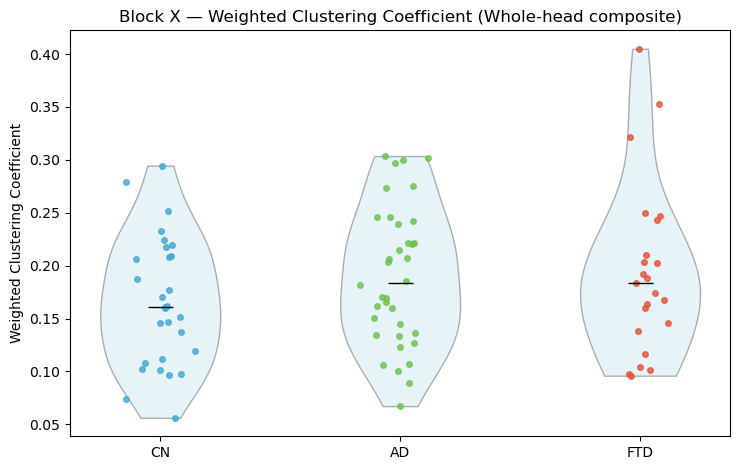

[✓] Figure saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/blockX/blockX_clust_coeff_violin_match.png


In [29]:
# =====================================================
# Block X — Violin Plot of Clustering Coefficient
# =====================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
STATS_DIR = ROOT / "outputs" / "connectivity" / "stats" / "blockX"

# ---------- Load ----------
df_graph = pd.read_csv(STATS_DIR / "blockX_graph_metrics.csv")

order = ["CN", "AD", "FTD"]
df_graph["group"] = pd.Categorical(df_graph["group"], categories=order, ordered=True)
df_graph = df_graph.sort_values("group")

# ---------- Violin data ----------
groups = [g for g in order if g in set(df_graph["group"])]
data = [df_graph.loc[df_graph["group"] == g, "clust_coeff"].values for g in groups]

plt.figure(figsize=(7.5, 4.8))
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)

# --- styling: same as Blocks 1–3 ---
for pc in parts["bodies"]:
    pc.set_facecolor("lightblue")
    pc.set_edgecolor("black")
    pc.set_alpha(0.3)

# --- scatter dots (group-colored) ---
dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN, AD, FTD colors
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    if len(vals) == 0:
        continue
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

# --- medians ---
medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians,
         marker="_", linestyle="none", color="black", markersize=18)

# --- axis labels & title ---
plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Weighted Clustering Coefficient")
plt.title("Block X — Weighted Clustering Coefficient (Whole-head composite)")

plt.grid(False)
plt.tight_layout()

out_path = STATS_DIR / "blockX_clust_coeff_violin_match.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"[✓] Figure saved → {out_path}")

